In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter, HourLocator, MinuteLocator
import matplotlib.dates as mdates
import datetime as dt
import warnings

warnings.filterwarnings('ignore')

# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 22
plt.rcParams['axes.unicode_minus'] = False

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Step 1: Data Loading and Time Processing

In [49]:
# Read data
try:
    df = pd.read_excel('CO2_capacity.xlsx', engine='openpyxl')
    print(f"✓ Data loaded successfully, shape: {df.shape}")
except Exception as e:
    raise RuntimeError(f"Read failed: {e}")

# Extract column information
time_col = df.columns[0]  # First column is time
target_col = df.columns[-1]  # Last column is CO2

print(f"\nBasic data information:")
print(f"  • Number of samples: {len(df)}")
print(f"  • Time column: {time_col}")
print(f"  • Target column: {target_col}")
print(f"  • Data span: about {len(df)/60:.1f} hours ({len(df)} minutes)")

# Selected 11 features
selected_features = ['TI-34', 'TI-33',  'FI-30', 'FI-38', 'TI-4', 'TI-19', 'TI-12', 'TI-22', 'TI-24','TI-28', 'Level Reboiler']

# Check whether selected features exist
missing_features = [f for f in selected_features if f not in df.columns]
if missing_features:
    print(f"\n⚠ Warning: The following features are missing: {missing_features}")
    print(f"Actual column names: {list(df.columns)}")
    selected_features = [f for f in selected_features if f in df.columns]

print(f"\nFeatures in use (total {len(selected_features)}):")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

✓ Data loaded successfully, shape: (7200, 59)

Basic data information:
  • Number of samples: 7200
  • Time column: Date
  • Target column: CO2 capacity
  • Data span: about 120.0 hours (7200 minutes)

Features in use (total 11):
  1. TI-34
  2. TI-33
  3. FI-30
  4. FI-38
  5. TI-4
  6. TI-19
  7. TI-12
  8. TI-22
  9. TI-24
  10. TI-28
  11. Level Reboiler


Data information:
  • Number of samples: 7200
  • Time range: 2020-01-20 00:00:00 to 2020-01-24 23:59:00
  • Time span: 4 days
✓ TI-34 scatter plot saved as TI-34_scatter.png


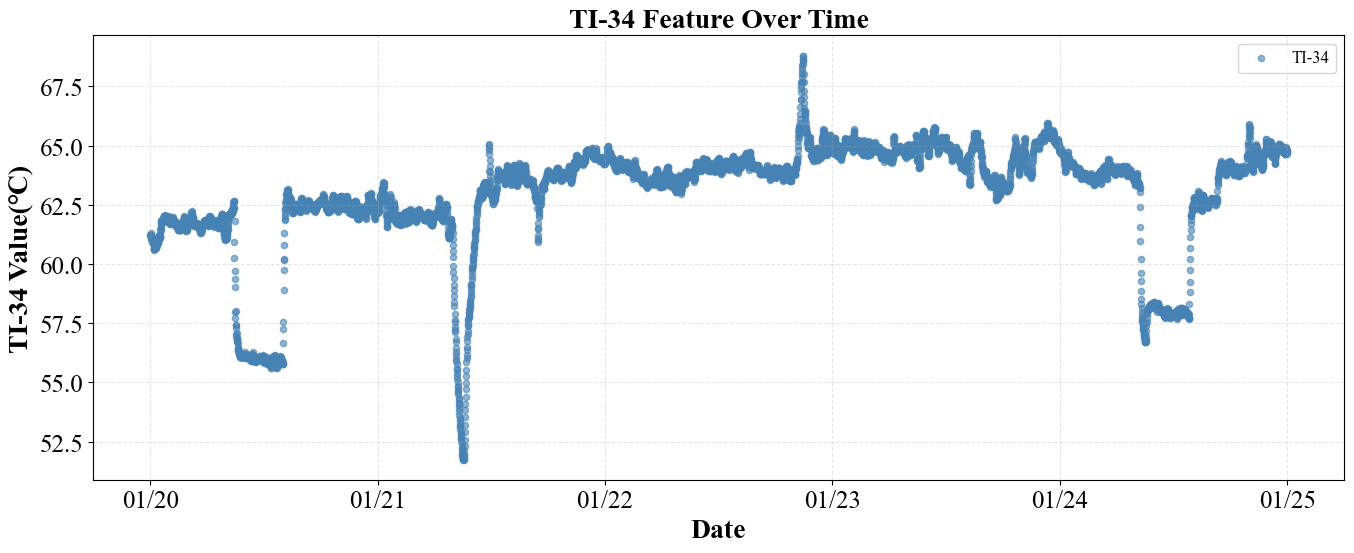

In [50]:
# Extract TI-34 data
ti34_data = df['TI-34'].values

# ---------------------------
#   Use real time-series data
# ---------------------------
# Ensure the time column is in datetime format
if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
    df[time_col] = pd.to_datetime(df[time_col])

time_index = df[time_col]

print(f"Data information:")
print(f"  • Number of samples: {len(df)}")
print(f"  • Time range: {time_index.min()} to {time_index.max()}")
print(f"  • Time span: {(time_index.max() - time_index.min()).days} days")

# ---------------------------
#   Plot scatter chart with actual time
# ---------------------------
fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(time_index, ti34_data, alpha=0.6, s=20, color='steelblue', label='TI-34')

# ---------------------------
#   Set date ticks on x-axis (one per day)
# ---------------------------
ax.xaxis.set_major_locator(mdates.DayLocator())               # One major tick per day
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))   # Month/day format

# Disable minor ticks
ax.minorticks_off()

# ---------------------------
#   Labels and title
# ---------------------------
ax.set_xlabel('Date', fontsize=20, fontweight='bold')
ax.set_ylabel('TI-34 Value(℃)', fontsize=20, fontweight='bold')
ax.set_title('TI-34 Feature Over Time', fontsize=20, fontweight='bold')
ax.tick_params(axis='both', labelsize=18)

ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('TI-34_scatter.png', dpi=300, bbox_inches='tight')
print("✓ TI-34 scatter plot saved as TI-34_scatter.png")
plt.show()


## Step 3: Scatter Plots for the Other 10 Features

✓ TI-33 scatter plot saved as TI-33_scatter.png


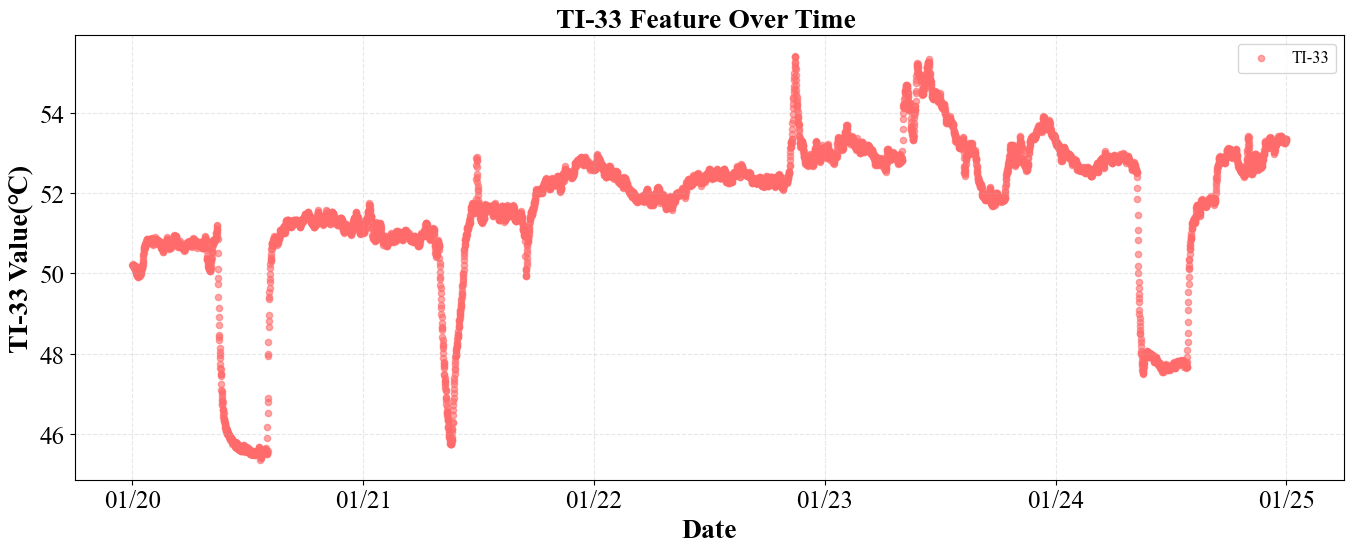


TI-33 Statistics:
  • Min: 45.3764
  • Max: 55.4159
  • Mean: 51.6473
  • Std: 1.8973
  • Samples: 7200

✓ FI-30 scatter plot saved as FI-30_scatter.png


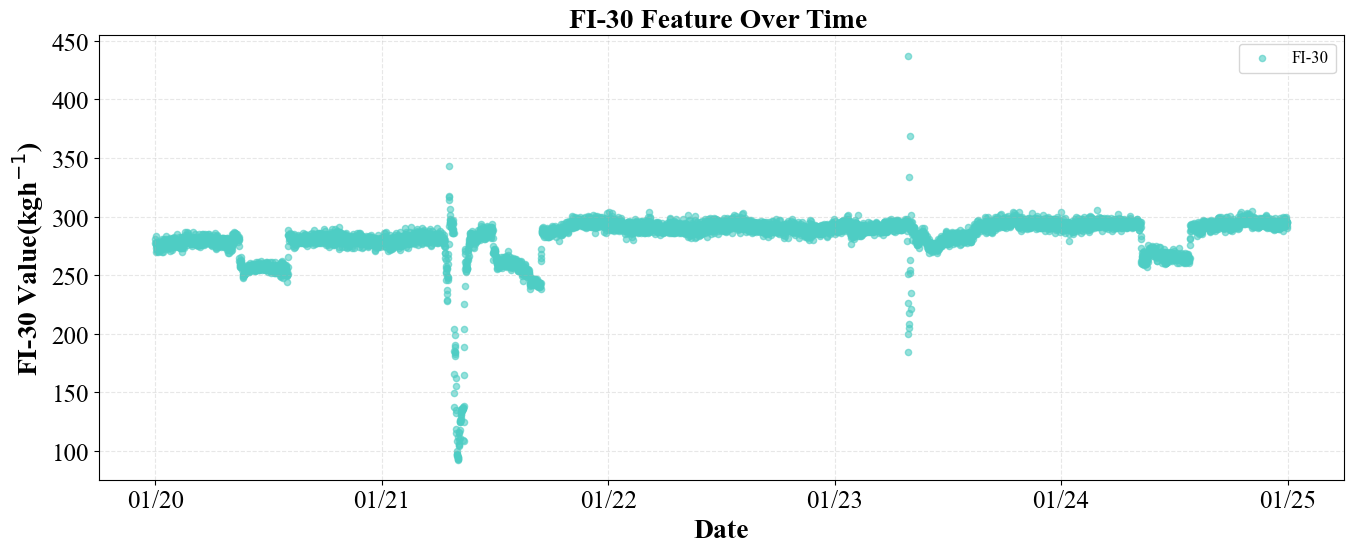


FI-30 Statistics:
  • Min: 92.6589
  • Max: 437.4948
  • Mean: 282.7689
  • Std: 19.4377
  • Samples: 7200

✓ FI-38 scatter plot saved as FI-38_scatter.png


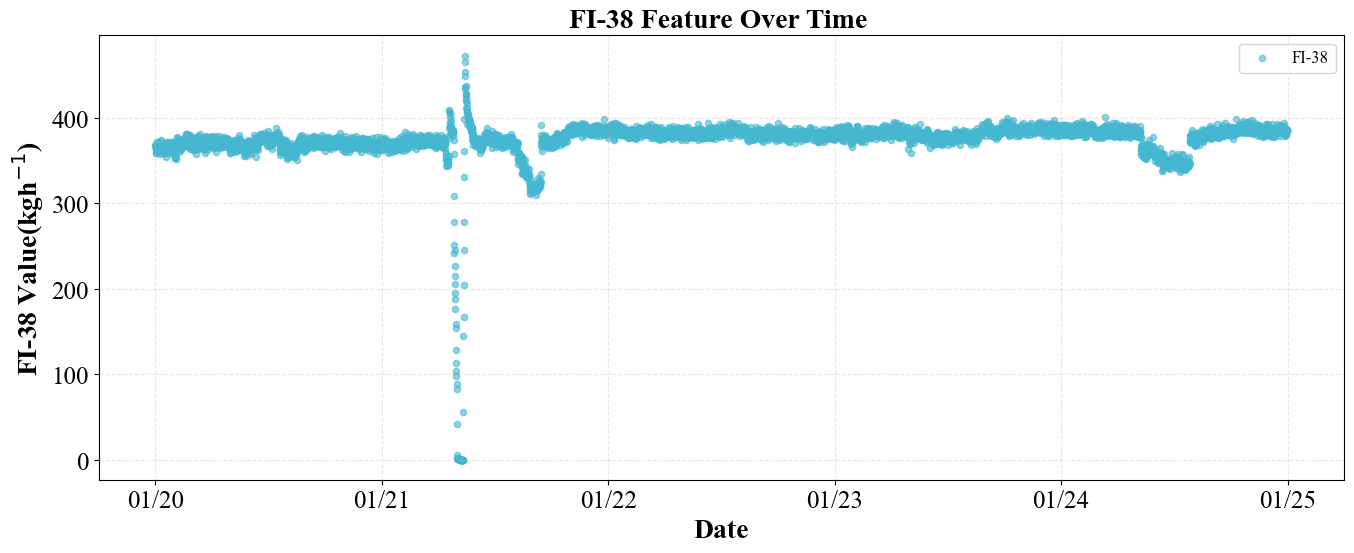


FI-38 Statistics:
  • Min: 0.0700
  • Max: 473.1332
  • Mean: 374.0831
  • Std: 32.6471
  • Samples: 7200

✓ TI-4 scatter plot saved as TI-4_scatter.png


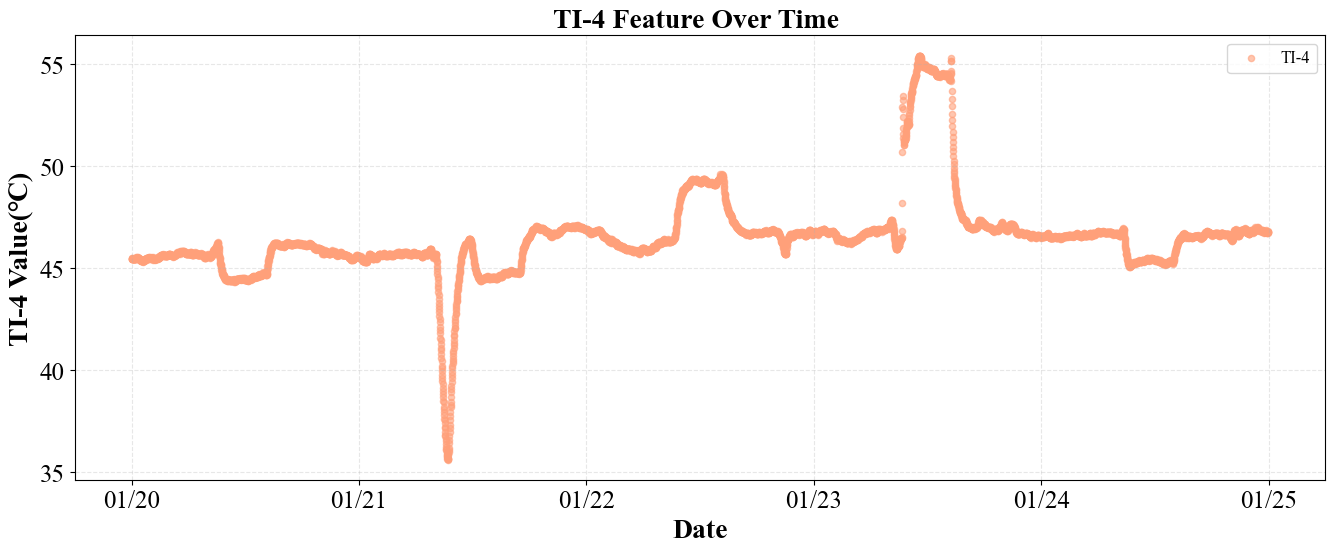


TI-4 Statistics:
  • Min: 35.6009
  • Max: 55.4248
  • Mean: 46.5302
  • Std: 2.1234
  • Samples: 7200

✓ TI-19 scatter plot saved as TI-19_scatter.png


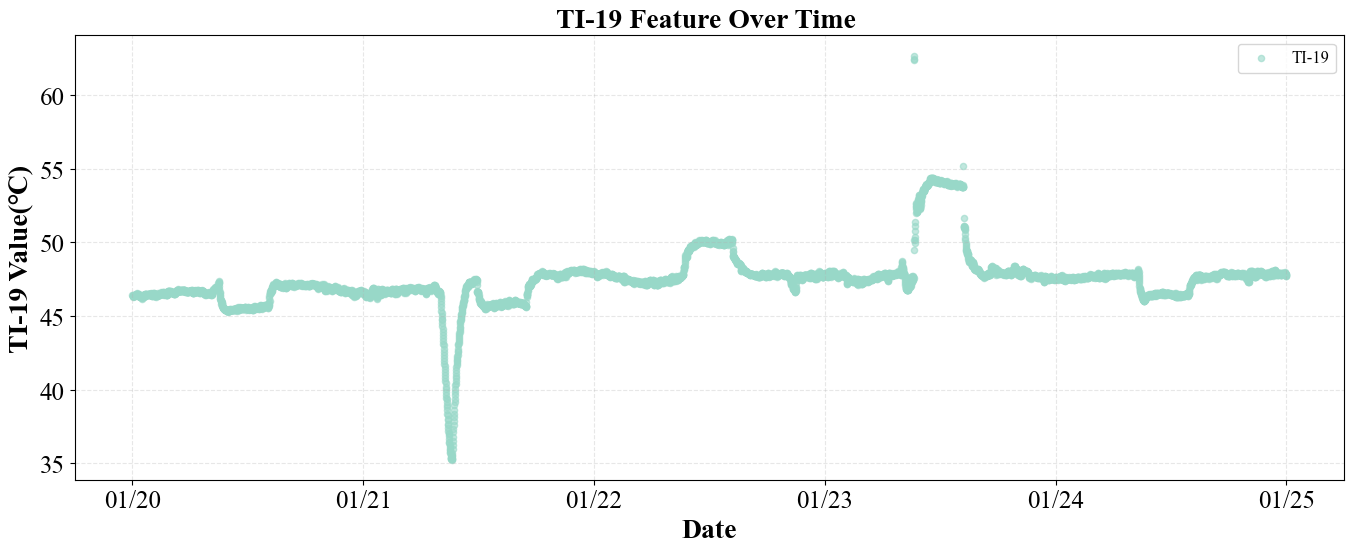


TI-19 Statistics:
  • Min: 35.2614
  • Max: 62.6641
  • Mean: 47.4940
  • Std: 1.9201
  • Samples: 7200

✓ TI-12 scatter plot saved as TI-12_scatter.png


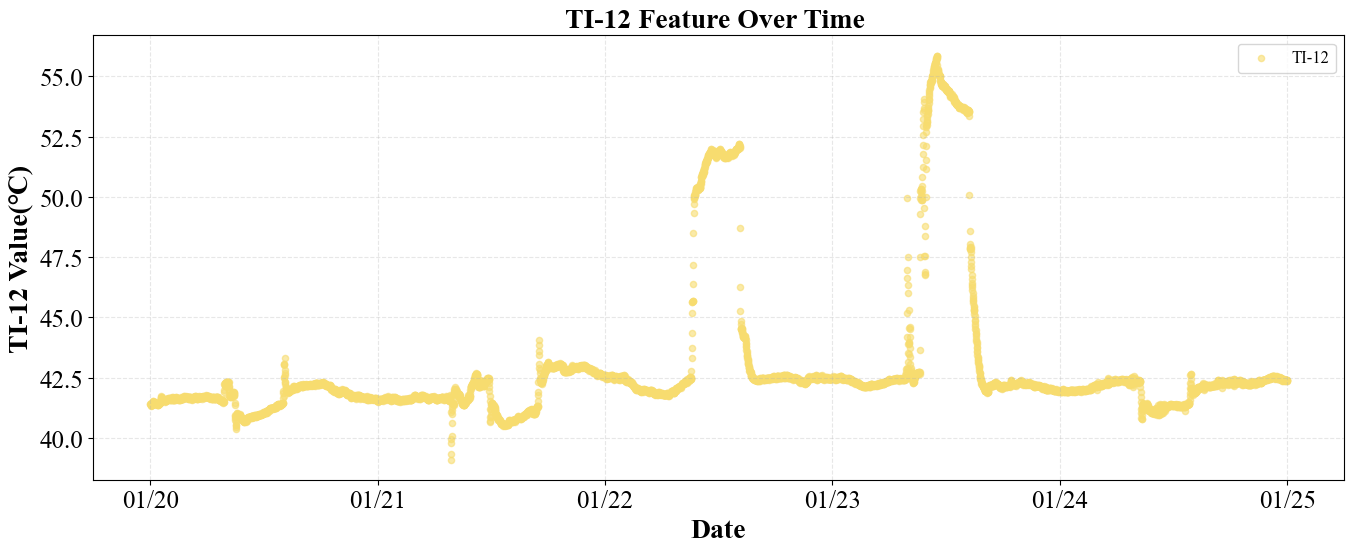


TI-12 Statistics:
  • Min: 39.0961
  • Max: 55.8632
  • Mean: 42.9551
  • Std: 3.0711
  • Samples: 7200

✓ TI-22 scatter plot saved as TI-22_scatter.png


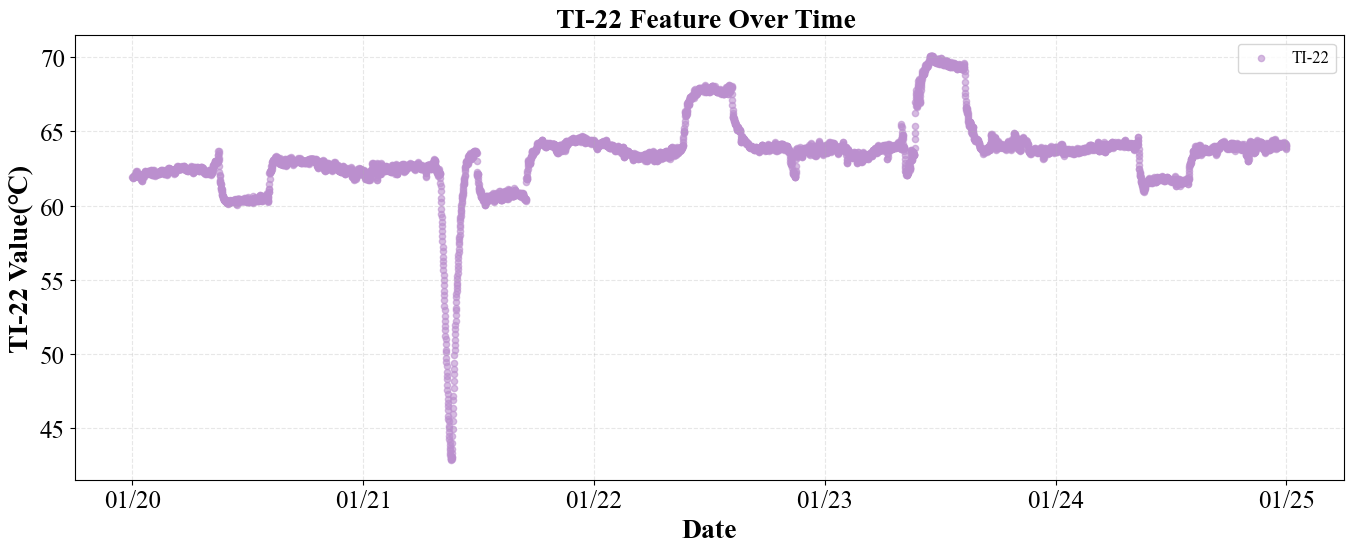


TI-22 Statistics:
  • Min: 42.9025
  • Max: 70.1113
  • Mean: 63.3547
  • Std: 2.5644
  • Samples: 7200

✓ TI-24 scatter plot saved as TI-24_scatter.png


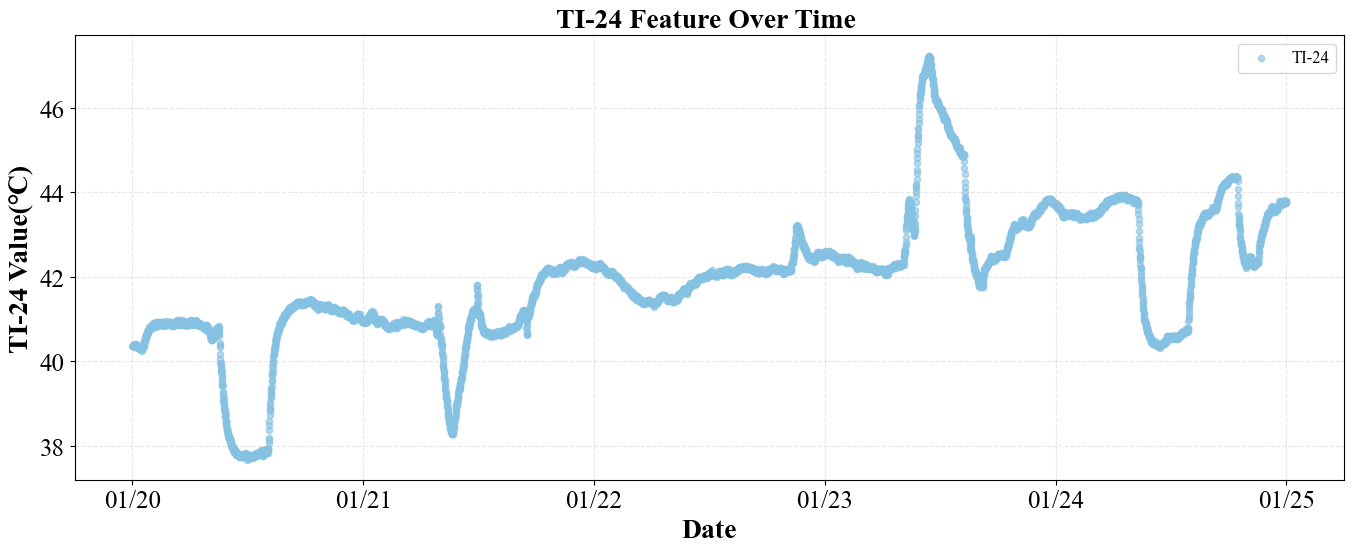


TI-24 Statistics:
  • Min: 37.6834
  • Max: 47.2303
  • Mean: 41.9237
  • Std: 1.5749
  • Samples: 7200

✓ TI-28 scatter plot saved as TI-28_scatter.png


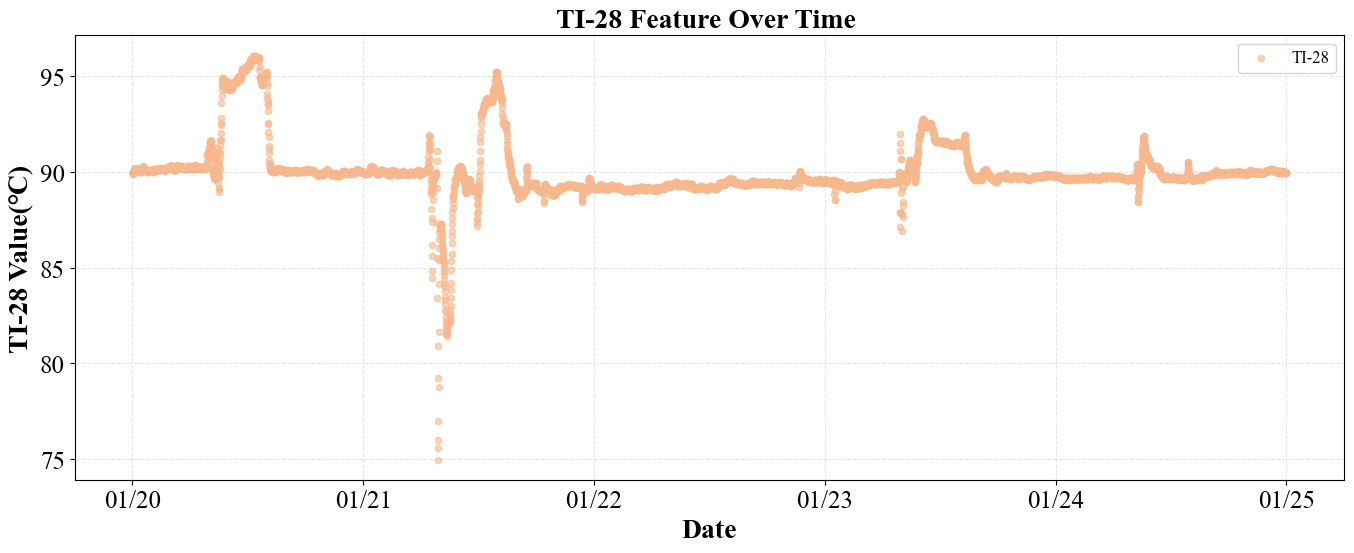


TI-28 Statistics:
  • Min: 74.9712
  • Max: 96.0832
  • Mean: 90.0031
  • Std: 1.5474
  • Samples: 7200

✓ Level Reboiler scatter plot saved as Level Reboiler_scatter.png


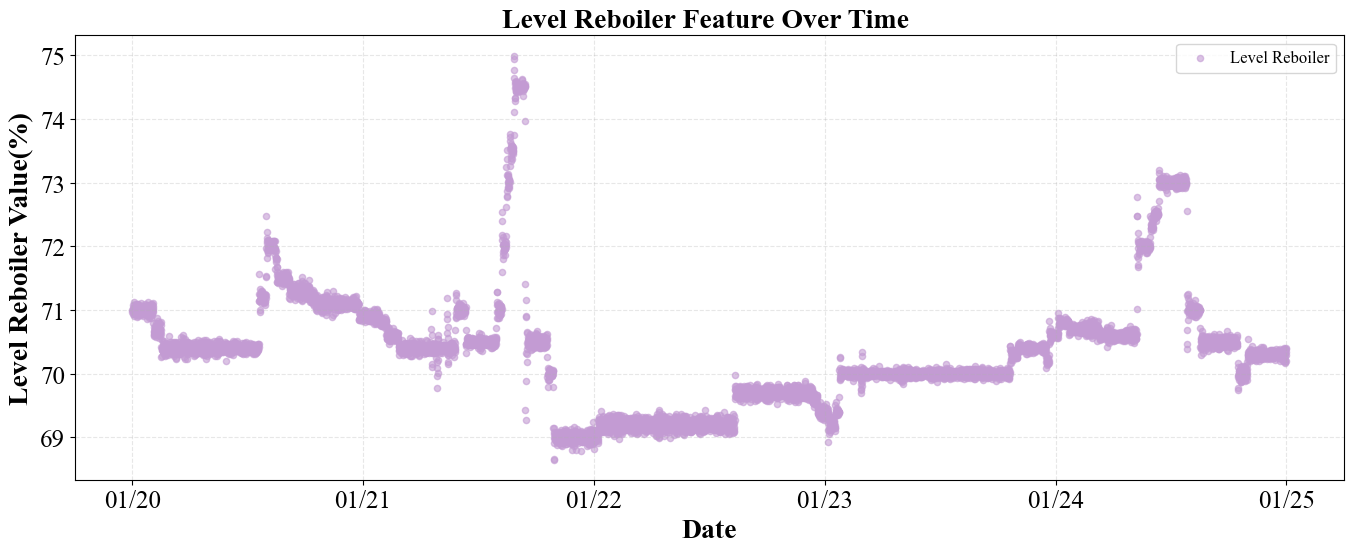


Level Reboiler Statistics:
  • Min: 68.6523
  • Max: 74.9953
  • Mean: 70.3736
  • Std: 0.9478
  • Samples: 7200



In [51]:
# Plot scatter charts for the other 10 features
other_features = ['TI-33', 'FI-30', 'FI-38', 'TI-4', 'TI-19', 'TI-12', 'TI-22', 'TI-24', 'TI-28', 'Level Reboiler']
colors_map = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E2', '#F8B88B', '#C39BD3']

for feature, color in zip(other_features, colors_map):
    if feature not in df.columns:
        print(f"⚠ Feature {feature} does not exist, skipped")
        continue
    
    feature_data = df[feature].values
    
    # Set unit based on feature name
    if feature.startswith('TI-'):
        unit = '(℃)'
    elif feature.startswith('FI-'):
        unit = '(kgh$^{-1}$)'
    elif feature == 'Level Reboiler':
        unit = '(%)'
    else:
        unit = ''
    
    # Plot scatter chart
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.scatter(time_index, feature_data, alpha=0.6, s=20, color=color, label=feature)
    
    # Set x-axis date ticks
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    
    # Disable minor ticks
    ax.minorticks_off()
    
    # Labels and title
    ax.set_xlabel('Date', fontsize=20, fontweight='bold')
    ax.set_ylabel(f'{feature} Value{unit}', fontsize=20, fontweight='bold')
    ax.set_title(f'{feature} Feature Over Time ', fontsize=20, fontweight='bold')
    ax.tick_params(axis='both', labelsize=18)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=12)
    
    # Save and display
    filename = f'{feature}_scatter.png'
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✓ {feature} scatter plot saved as {filename}")
    plt.show()
    
    # Display statistics
    print(f"\n{feature} Statistics:")
    print(f"  • Min: {feature_data.min():.4f}")
    print(f"  • Max: {feature_data.max():.4f}")
    print(f"  • Mean: {feature_data.mean():.4f}")
    print(f"  • Std: {feature_data.std():.4f}")
    print(f"  • Samples: {len(feature_data)}\n")

## Step 4: CO2 Capture Rate Scatter Plot

✓ CO2 scatter plot saved as CO2_scatter.png


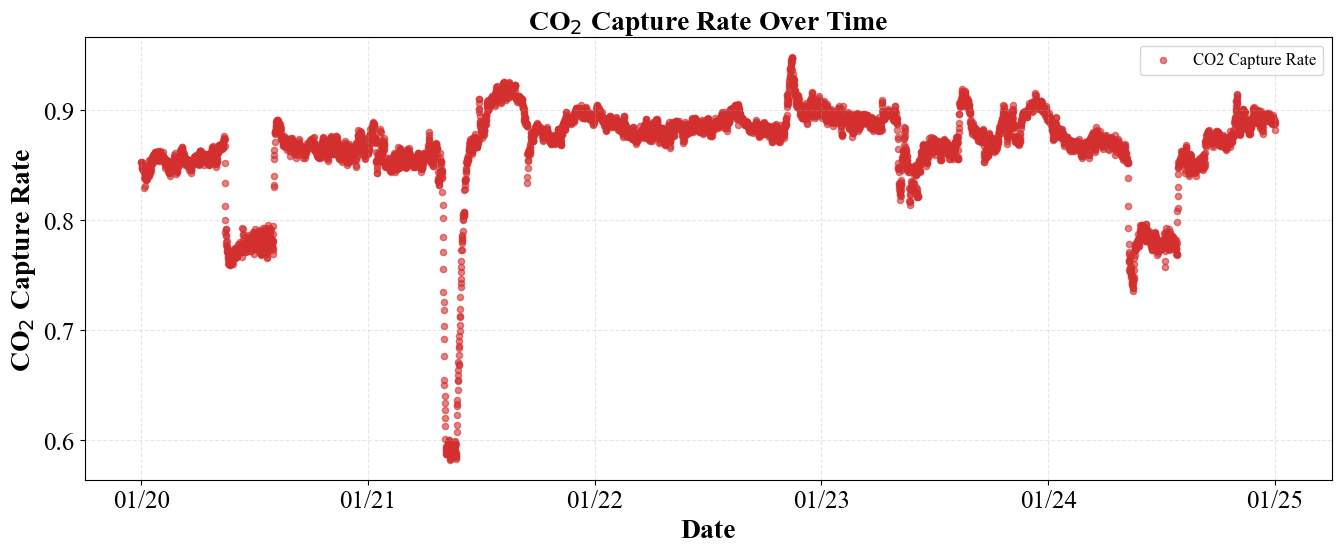

In [52]:
# Plot CO2 capture rate scatter chart
co2_data = df[target_col].values

fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(time_index, co2_data, alpha=0.6, s=20, color='#D32F2F', label='CO2 Capture Rate')

# Set x-axis date ticks
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))

# Disable minor ticks
ax.minorticks_off()

# Labels and title
ax.set_xlabel('Date', fontsize=20, fontweight='bold')
ax.set_ylabel('CO$_{2}$ Capture Rate', fontsize=20, fontweight='bold')
ax.set_title('CO$_{2}$ Capture Rate Over Time', fontsize=20, fontweight='bold')
ax.tick_params(axis='both', labelsize=18)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=12)

# Save and display
plt.tight_layout()
plt.savefig('CO2_scatter.png', dpi=300, bbox_inches='tight')
print("✓ CO2 scatter plot saved as CO2_scatter.png")
plt.show()



## Step 5: Data Normalization and Trend Analysis

In [53]:
# Data normalization analysis - Min-Max scaling
# Formula: X_normalized = (X - min(X)) / (max(X) - min(X))

print("=" * 60)
print("Data Normalization Explanation")
print("=" * 60)
print("\nNormalization Method: Min-Max Scaling")
print("Formula: X_normalized = (X - min) / (max - min)")
print("\nKey Properties:")
print("  ✓ Preserves original data trends (relative relationships unchanged)")
print("  ✓ Only changes data scale and position")
print("  ✓ Does not affect monotonicity and relative changes")
print("  ✓ Normalized data range: [0, 1]")

# Extract all features and CO2 (11 selected features)
all_features = ['TI-34', 'TI-33', 'FI-30', 'FI-38', 'TI-4', 'TI-19', 'TI-12', 'TI-22', 'TI-24', 'TI-28', 'Level Reboiler']
features_data = {}
for feat in all_features:
    if feat in df.columns:
        features_data[feat] = df[feat].values
    else:
        print(f"⚠ Feature {feat} does not exist")

co2_original = df[target_col].values

# Normalization function
def normalize_minmax(x):
    return (x - x.min()) / (x.max() - x.min())

# Normalize all data
features_normalized = {}
for feat in all_features:
    features_normalized[feat] = normalize_minmax(features_data[feat])

co2_normalized = normalize_minmax(co2_original)

print("\nNormalization Results:")
print(f"  • All features and CO2 normalized to [0, 1] range")
print(f"  • Trend: Fully preserved (unchanged)")
print(f"  • Can be directly compared in the same plot")

# Validation: correlation between original and normalized data (should be 1)
print("\nValidation of Normalization (correlation between original and normalized data):")
for feat in all_features[:3]:  # Show the first 3 features as examples
    corr = np.corrcoef(features_data[feat], features_normalized[feat])[0, 1]
    print(f"  • {feat}: Correlation = {corr:.10f} ≈ 1.0 ✓")

Data Normalization Explanation

Normalization Method: Min-Max Scaling
Formula: X_normalized = (X - min) / (max - min)

Key Properties:
  ✓ Preserves original data trends (relative relationships unchanged)
  ✓ Only changes data scale and position
  ✓ Does not affect monotonicity and relative changes
  ✓ Normalized data range: [0, 1]

Normalization Results:
  • All features and CO2 normalized to [0, 1] range
  • Trend: Fully preserved (unchanged)
  • Can be directly compared in the same plot

Validation of Normalization (correlation between original and normalized data):
  • TI-34: Correlation = 1.0000000000 ≈ 1.0 ✓
  • TI-33: Correlation = 1.0000000000 ≈ 1.0 ✓
  • FI-30: Correlation = 1.0000000000 ≈ 1.0 ✓


## Step 6: Combined Scatter Plots of All Features and CO2 (Normalized)


[Figure 1] Plotting first 5 features + CO2 capture rate...
✓ First figure saved as features_group1_co2_normalized.png


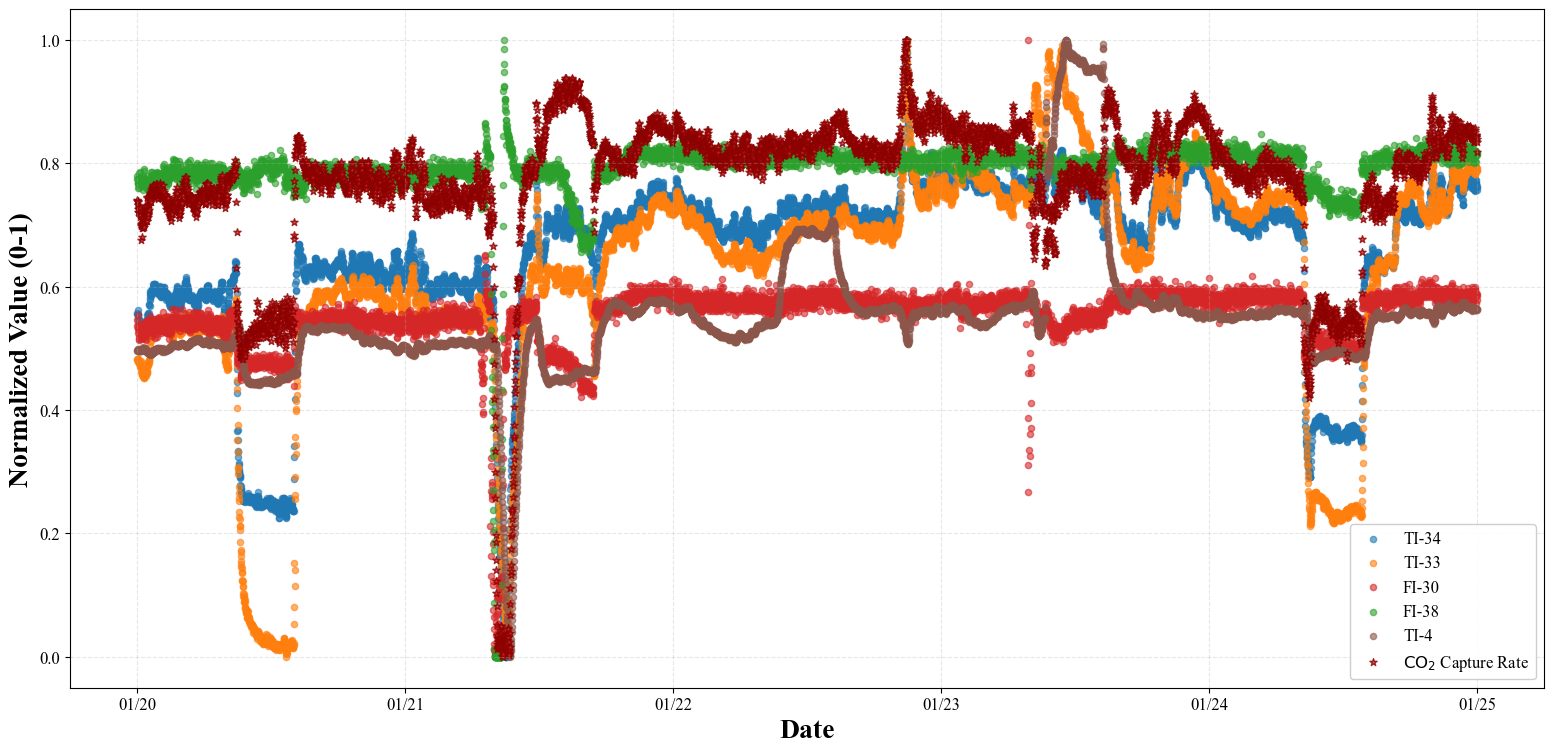


[Figure 2] Plotting remaining 6 features + CO2 capture rate...

[Figure 2] Plotting remaining 6 features + CO2 capture rate...
✓ Second figure saved as features_group2_co2_normalized.png


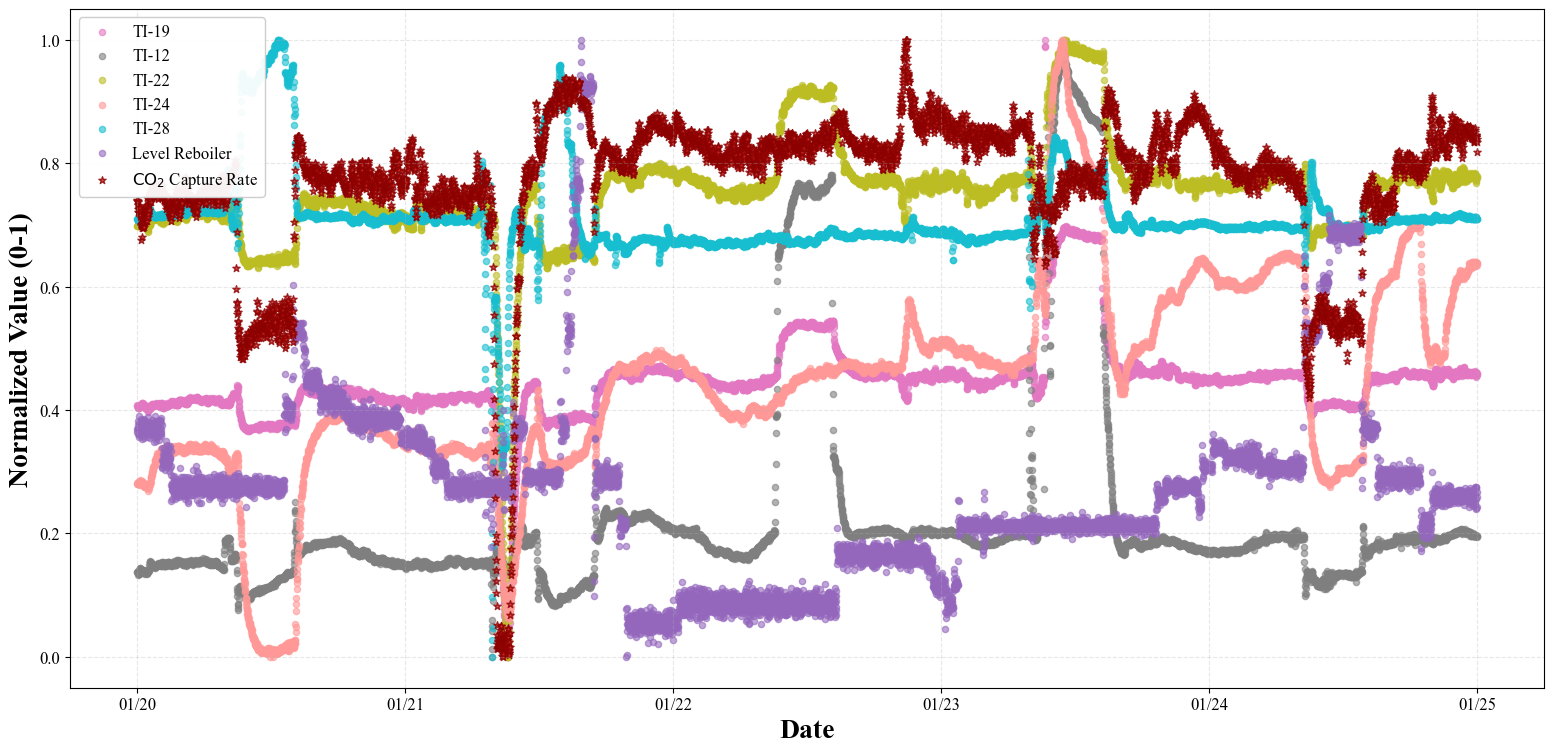

Statistical Summary of Normalized Data
Summary statistics for normalized data

Feature    Min        Max        Mean       Std       

Feature    Min        Max        Mean       Std       
--------------------------------------------------
TI-34      0.0000     1.0000     0.6560     0.1409    
TI-33      0.0000     1.0000     0.6246     0.1890    
FI-30      0.0000     1.0000     0.5513     0.0564    
FI-38      0.0000     1.0000     0.7906     0.0690    
TI-4       0.0000     1.0000     0.5513     0.1071    
TI-19      0.0000     1.0000     0.4464     0.0701    
TI-12      0.0000     1.0000     0.2302     0.1832    
TI-22      0.0000     1.0000     0.7517     0.0942    
TI-24      0.0000     1.0000     0.4442     0.1650    
TI-28      0.0000     1.0000     0.7120     0.0733    
Level Reboiler 0.0000     1.0000     0.2714     0.1494    
CO2        0.0000     1.0000     0.7722     0.1253    


In [ ]:
# Ensure the time column is datetime and extract time_index
if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
    df[time_col] = pd.to_datetime(df[time_col])
time_index = df[time_col]

# Define color mapping (11 features)
colors_all = {
    'TI-34': '#1f77b4',        # Blue
    'TI-33': '#ff7f0e',        # Orange
    'FI-30': '#d62728',        # Red
    'FI-38': '#2ca02c',        # Green
    'TI-4': '#8c564b',         # Brown
    'TI-19': '#e377c2',        # Pink
    'TI-12': '#7f7f7f',        # Gray
    'TI-22': '#bcbd22',        # Yellow-green
    'TI-24': '#ff9896',        # Light red
    'TI-28': '#17becf',        # Cyan
    'Level Reboiler': '#9467bd',  # Purple
    'CO2': '#D32F2F'           # Dark red (highlight CO2)
}

# Split into two feature groups: first 5 + remaining 6
features_group1 = ['TI-34', 'TI-33', 'FI-30', 'FI-38', 'TI-4']
features_group2 = ['TI-19', 'TI-12', 'TI-22', 'TI-24', 'TI-28', 'Level Reboiler']

print("\n[Figure 1] Plotting first 5 features + CO2 capture rate...")

# ===== Figure 1: first 5 features + CO2 =====
fig1, ax1 = plt.subplots(figsize=(16, 8))

# Plot first 5 features
for feat in features_group1:
    ax1.scatter(time_index, features_normalized[feat], alpha=0.6, s=20, 
              color=colors_all[feat], label=feat, marker='o')

# Plot CO2 (highlighted)
ax1.scatter(time_index, co2_normalized, alpha=0.8, s=30, 
          color=colors_all['CO2'], label='$\\mathrm{CO_2}$ Capture Rate', marker='*', edgecolors='darkred', linewidth=1)

# Set x-axis date ticks
ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))

# Disable minor ticks
ax1.minorticks_off()

# Labels and title
ax1.set_xlabel('Date', fontsize=20, fontweight='bold')
ax1.set_ylabel('Normalized Value (0-1)', fontsize=20, fontweight='bold')
ax1.tick_params(axis='both', labelsize=12)
ax1.grid(True, alpha=0.3, linestyle='--')

# Set y-axis range
ax1.set_ylim(-0.05, 1.05)

# Add legend
ax1.legend(loc='best', fontsize=12, framealpha=0.95)

plt.tight_layout()
plt.savefig('features_group1_co2_normalized.png', dpi=300, bbox_inches='tight')
print("✓ First figure saved as features_group1_co2_normalized.png")
plt.show()
print("\n[Figure 2] Plotting remaining 6 features + CO2 capture rate...")

# ===== Figure 2: remaining 6 features + CO2 =====
fig2, ax2 = plt.subplots(figsize=(16, 8))

# Plot remaining 6 features
for feat in features_group2:
    ax2.scatter(time_index, features_normalized[feat], alpha=0.6, s=20, 
              color=colors_all[feat], label=feat, marker='o')

# Plot CO2 (highlighted)
ax2.scatter(time_index, co2_normalized, alpha=0.8, s=30, 
          color=colors_all['CO2'], label='$\\mathrm{CO_2}$ Capture Rate', marker='*', edgecolors='darkred', linewidth=1)

# Set x-axis date ticks
ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))

# Disable minor ticks
ax2.minorticks_off()

ax2.set_xlabel('Date', fontsize=20, fontweight='bold')
ax2.set_ylabel('Normalized Value (0-1)', fontsize=20, fontweight='bold')
ax2.tick_params(axis='both', labelsize=12)
ax2.grid(True, alpha=0.3, linestyle='--')

# Set y-axis range
ax2.set_ylim(-0.05, 1.05)

# Add legend
ax2.legend(loc='best', fontsize=12, framealpha=0.95)

plt.tight_layout()
plt.savefig('features_group2_co2_normalized.png', dpi=300, bbox_inches='tight')
print("✓ Second figure saved as features_group2_co2_normalized.png")
plt.show()

# Display statistical summary
print("Statistical Summary of Normalized Data")
print(f"\n{'Feature':<10} {'Min':<10} {'Max':<10} {'Mean':<10} {'Std':<10}")
print("-" * 50)
for feat in all_features:
    data = features_normalized[feat]
    print(f"{feat:<10} {data.min():<10.4f} {data.max():<10.4f} {data.mean():<10.4f} {data.std():<10.4f}")

print(f"{'CO2':<10} {co2_normalized.min():<10.4f} {co2_normalized.max():<10.4f} {co2_normalized.mean():<10.4f} {co2_normalized.std():<10.4f}")

print("=" * 60)
print("=" * 60)